# Model Evaluation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error)
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from project.data_processing.model import (X_train, y_train, regressor, X_test, y_test)

## 1. Hyperparameter Tuning

In [2]:
def cross_val():
    """
    Performing a one-time hyperparameter tuning using GridSearchCV with 5-fold cross validation.
    Prints best set of hyperparameters and its R2 score.
    Not used in final training.
    """

    param_grid = {
        'max_depth': [5, 10, 15, None],
        'n_estimators': [100, 200],
        'min_samples_leaf': [2, 4],
        'min_samples_split': [5, 10]
    }

    rf = RandomForestRegressor(random_state=42)
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        scoring='r2',
        cv=5
    )

    grid_search.fit(X_train, y_train)
    best_estimator_number = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    print("Best parameters:", best_params)
    print("Best R2 score:", best_score)

This best set of hyperparameters obtained from 5-fold cross validation is the set of hyperparameters used in the model (as shown below).

```python
regressor = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=4,
    min_samples_split=5,
    random_state=42
)

## 2. Test Set Performance Metrics

In [ ]:
y_predicted = regressor.predict(X_test)

r2 = regressor.score(X_test, y_test)
mae = mean_absolute_error(y_test, y_predicted)
rmse = np.sqrt(mean_squared_error(y_test, y_predicted))

print(f"r2: {r2:.4f}")
print(f"mae: {mae:.4f}")
print(f"rmse: {rmse:.4f}")

# Calculation of average error % since target variable was log-normalised
avg_error = np.exp(mae) - 1
print(f"average error: {avg_error:.4f}")

```markdown
r2: 0.5486
mae: 0.4349
rmse: 0.8949
average error: 0.5447
```
---

**Interpretation of Metrics**

The final Random Forest model achieved an R2 of 0.55 on the test set, indicating that about half of the variance in Spotify stream counts can be explained using only audio features, playlist exposure and the timing when the song is released.

As stream counts are log-normalised, the MAE of 0.43 corresponds to the predicted stream counts typically being within about 1.54 times of the true stream count (when the stream counts are converted back to the original magnitudes).

RMSE being higher than MAE implies that although the model performs reasonably well for most songs, at the extreme ends of the stream count spectrum, some stream counts remain difficult to predict accurately. 

## 3. Analysis of Residuals

### 3.1 Residuals vs Predictions (log space)

In [ ]:
resids = y_test - y_predicted

plt.scatter(y_predicted, resids, alpha=0.5)
plt.axhline(0, color="red")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictions")
plt.show()

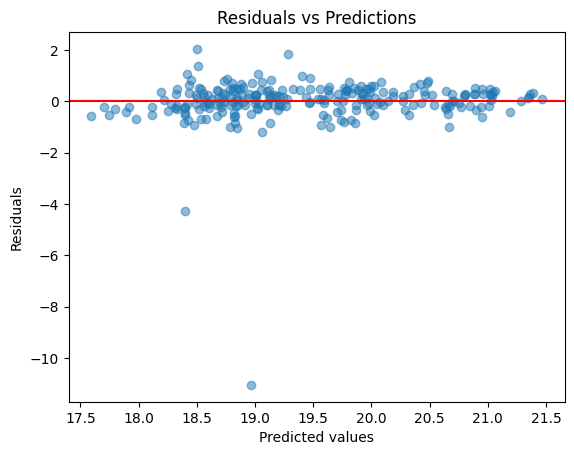

In [ ]:
relative_error = np.abs(resids) / np.maximum(np.abs(y_test), 1e-8)
print(np.mean(relative_error))

0.026090517679678574

**Interpretation of Residual Analysis**

Residual analysis shows that prediction errors are small and generally centered around 0. Most residuals fall between -1.5 and +2 on the log scale, suggesting good model calibration and minimal bias.

A very small minority of outliers show larger negative residuals, indicating that the model occasionally overestimates in rare cases. As RMSE is very sensitive to outliers, these rare cases disproportionately affect RMSE but do not significantly affect the model's behaviour.

The model achieved a low average relative error of about 2.6%. This demonstrates the model's strong predictive accruacy for most samples.

### 3.2 Predicted vs Actual Stream Counts (raw scale)

In [ ]:
# Transform to raw scale
y_test_raw = np.exp(y_test) - 1
y_predicted_raw = np.exp(y_predicted) - 1

plt.figure(figsize=(6,6))
plt.scatter(y_test_raw, y_predicted_raw, alpha=0.3, s=15)

min_value = max(y_test_raw.min(), y_predicted_raw.min())
max_value = max(y_test_raw.max(), y_predicted_raw.max())
plt.plot([min_value, max_value], [min_value, max_value])    # Diagonal line representing perfect prediction
plt.xscale("log")       # Use log-log scale
plt.yscale("log")
plt.xlim(1e6, 3e9)
plt.ylim(1e6, 3e9)
plt.xlabel("Actual Stream Count")
plt.ylabel("Predicted Stream Count")
plt.title("Predicted vs Actual Spotify Stream Counts (Raw Scale)")
plt.tight_layout()
plt.show()

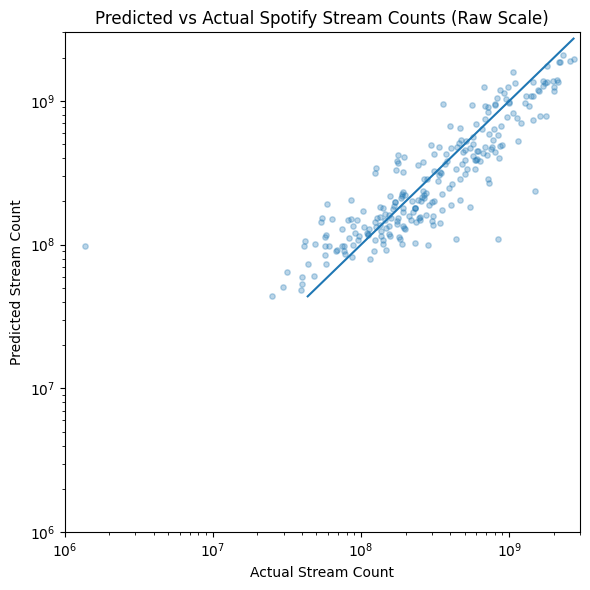

*Axes are restricted to the range containing the majority of observations.*

**Interpretation of Predicted vs Actual Plot**

The predicted vs actual plot in raw stream counts (log-log scale) shows partial alignment with the diagnoal line, indicating that the model preserves some relative ordering among moderately popular songs. However, the model's predictions are increasingly compressed at the upper tail, which causes the most highly streamed songs to be underestimated and absolute error to widen.

Given the optimisation in log space and how playlist exposure dominates as a predictive feature, this behaviour is expected and helps to explain how *absolute* errors are higher for songs in the highest popularity quartile. Overall, while the model performs reasonably in distinguishing low-to-mid popularity songs, it under-differentiates among extremely popular songs.

## 4. Error Analysis by Stream Count Quantiles (Error Stratification by Popularity Range)

In [ ]:
df_error = pd.DataFrame({
    "y_actual": y_test,
    "y_predicted": y_predicted,
    "relative_error": relative_error})

df_error["category"] = pd.qcut(df_error["y_actual"], q=4, labels=["low-streams", "mid-low streams", "mid-high streams", "popular"])
df_error.groupby("category")["relative_error"].mean()

```markdown
category
low-streams         0.049168
mid-low streams     0.015803
mid-high streams    0.019774
popular             0.019239
Name: relative_error, dtype: float64
```

To better understand how prediction accuracy varies across the target variable's distribution, relative error was analysed across quartiles of actual stream counts.

<table>
    <thead>
        <th>Popularity Group</th>
        <th>Mean Relative Error</th>
    </thead>
    <tbody>
        <tr>
            <td>Low streams</td>
            <td>~ 4.9%</td>
        </tr>
        <tr>
            <td>Mid-low streams</td>
            <td>~ 1.6%</td>
        </tr>
        <tr>
            <td>Mid-high streams</td>
            <td>~ 2.0%</td>
        </tr>
        <tr>
            <td>Popular</td>
            <td>~ 1.9%</td>
        </tr>
    </tbody>
</table>

Although one might hypothesise that relative error is higher for highly popular songs due to the influence of many external factors not captured in the dataset, the results observed suggest otherwise. This can be largely attributed to the use of a *relative* (i.e., proportional) error metric, which is less sensitive for large target values. 

Moreover, ensemble models like Random Forest tend to generate predictions that regress extreme cases towards the mean. As a result, while *absolute* errors for highly popular songs may be larger, on average the relative error remains low for this group of songs.

In [ ]:
df_error["absolute_error"] = np.abs(df_error["y_actual"] - df_error["y_predicted"])

df_error["category"] = pd.qcut(
    df_error["y_actual"],
    q=4,
    labels=["low streams", "mid-low streams", "mid-high streams", "popular"]
)

df_error.boxplot(
    column="absolute_error", 
    by="category",
    grid=False
)

plt.xlabel("Popularity Group")
plt.ylabel("Absolute Error")
plt.title("Absolute Error by Song Popularity Quartile")
plt.suptitle("")        # Remove default title
plt.show()

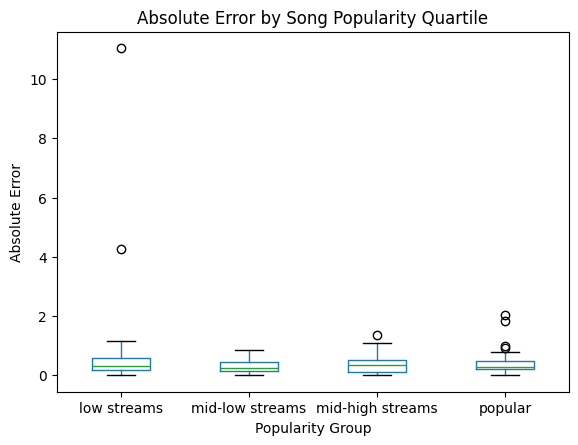

**Interpretation of Boxplot**

The quartile for popular songs shows one of the smaller interquartile ranges and one of the lower median absolute errors. This suggests that while there can occasionally be large errors in the predictions for highly popular songs, the model generally makes consistent predictions. 

From the boxplot, absolute error (measured in log units) not being the largest in the most popular songs is an intended outcome of log-normalisation that was performed on the target variable (which had a skewed distribution).

The boxplot also shows the characteristic behaviour of ensemble regressors, where extreme values tend to be shrunk towards the mean, reducing variance even when outliers have significant absolute errors.

## 5. Ablation Study: Effect of Playlist Exposure on Stream Count

To examine the importance of how exposed a song is in playlists, as an experiment, the model was retrained after removing the `in_spotify_playlists` feature (which contains the number of Spotify playlists containing the song).

```python
from .data_pipeline import df_no_nulls

df_cleaned = df_no_nulls.drop(['in_spotify_playlists'], axis=1)

**Results of Study**

<table>
    <thead>
        <th>Metric</th>
        <th>With Playlists</th>
        <th>Without Playlists</th>
    </thead>
    <tbody>
        <tr>
            <td>R2</td>
            <td>0.55</td>
            <td>0.37</td>
        </tr>
        <tr>
            <td>MAE</td>
            <td>0.43</td>
            <td>0.62</td>
        </tr>
        <tr>
            <td>RMSE</td>
            <td>0.89</td>
            <td>1.06</td>
        </tr>
    </tbody>
</table>


The drop in R2 corresponds to roughly a 34% reduction in the variance of Spotify stream counts explained by the model. MAE shows that predictions are off by approaching a doubling of error in raw stream counts and RMSE suggests that many predictions made by the model are significantly inaccurate (particularly for songs with high stream count).

Together, these results indicate that without information on playlist exposure, the model has difficulty distinguishing between moderately popular songs and highly popular hits.

The significant reduction in model performance shows that playlist exposure of a song is a significant predictor of Spotify stream counts. While audio features and release timing can capture some signal, they cannot sufficiently explain large variations in a song's popularity without taking into account playlist exposure. 

This experiment highlights the key limitation of feature-based prediction of Spotify stream counts: 
- **A song's metadata alone do not determine how commercially successful a song would be on Spotify**

## 6. Analysis of Features (Feature Importance)

In [ ]:
# Showing feature schema for transparency (raw data not included)
print(X_test.info())

```
<class 'pandas.DataFrame'>
Index: 245 entries, 196 to 404
Data columns (total 31 columns):
 #    Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   released_year         245 non-null    int64  
 1   in_spotify_playlists  245 non-null    int64  
 2   mode                  245 non-null    int64  
 3   key_A#                245 non-null    float64
 4   key_B                 245 non-null    float64
 5   key_C#                245 non-null    float64
 6   key_D                 245 non-null    float64
 7   key_D#                245 non-null    float64
 8   key_E                 245 non-null    float64
 9   key_F                 245 non-null    float64
 10  key_F#                245 non-null    float64
 11  key_G                 245 non-null    float64
 12  key_G#                245 non-null    float64
 13  released_month_2      245 non-null    float64
 14  released_month_3      245 non-null    float64
 15  released_month_4      245 non-null    float64
 16  released_month_5      245 non-null    float64
 17  released_month_6      245 non-null    float64
 18  released_month_7      245 non-null    float64
 19  released_month_8      245 non-null    float64
 20  released_month_9      245 non-null    float64
 21  released_month_10     245 non-null    float64
 22  released_month_11     245 non-null    float64
 23  released_month_12     245 non-null    float64
 24  bpm                   245 non-null    float64
 25  danceability_%        245 non-null    float64
 26  valence_%             245 non-null    float64
 27  energy_%              245 non-null    float64
 28  speechiness_%_log     245 non-null    float64
 29  liveness_%_log        245 non-null    float64
 30  acousticness_%_log    245 non-null    float64
dtypes: float64(28), int64(3)
memory usage: 61.2 KB
None
```

In [ ]:
def grouped_permutation_importance(model, X, y, feature_prefix, n_repeats=20, random_state=42):
    """
    Permutes all one-hot columns sharing the same prefix together to
    estimate the importance of the original categorical feature.
    """
    
    cols = [col for col in X.columns if col.startswith(feature_prefix)]
    baseline = model.score(X, y)

    rng = np.random.default_rng(random_state)
    drops = []      # Stores how much R2 decreases after each random permutation

    for _ in range(n_repeats):
        X_permuted = X.copy()
        shuffled_index = rng.permutation(len(X))
        # Shuffle together all grouped columns to break their relationship with the target
        X_permuted[cols] = X.iloc[shuffled_index][cols].values
        decrease_in_r2 = baseline - model.score(X_permuted, y)
        drops.append(decrease_in_r2)

    return np.mean(drops)


# Compute grouped permutation importance for release month and key
released_month_importance = grouped_permutation_importance(
    model=regressor,
    X=X_test,
    y=y_test,
    feature_prefix="released_month_",
    n_repeats=20,
    random_state=42
)
key_importance = grouped_permutation_importance(
    model=regressor,
    X=X_test,
    y=y_test,
    feature_prefix="key_",
    n_repeats=20,
    random_state=42
)

Dummy columns for a categorical feature are simultaneously permuted to measure the feature's overall contribution to the model by estimating the feature's effect as if it was removed.

In [ ]:
result = permutation_importance(
    regressor,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

importance_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": result.importances_mean,
    })
    .sort_values(by="importance_mean", ascending=False)
    .head(15)
)

# Remove one-hot month and key columns
importance_df = importance_df.loc[importance_df["feature"].str.startswith("released_month_") == False]
importance_df = importance_df.loc[importance_df["feature"].str.startswith("key_") == False]

# Append the grouped importance for released_month and key
importance_df = pd.concat([
    importance_df,
    pd.DataFrame({
        "feature": ["released_month", "key"],
        "importance_mean": [released_month_importance, key_importance]
    })
], ignore_index=True)

# Sort for plotting
importance_df = importance_df.sort_values(by="importance_mean", ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(
    importance_df["feature"],
    importance_df["importance_mean"],
)
plt.xlabel("Decrease in R2 After Permutation")
plt.title("Permutation Feature Importance (Grouped Months and Keys)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

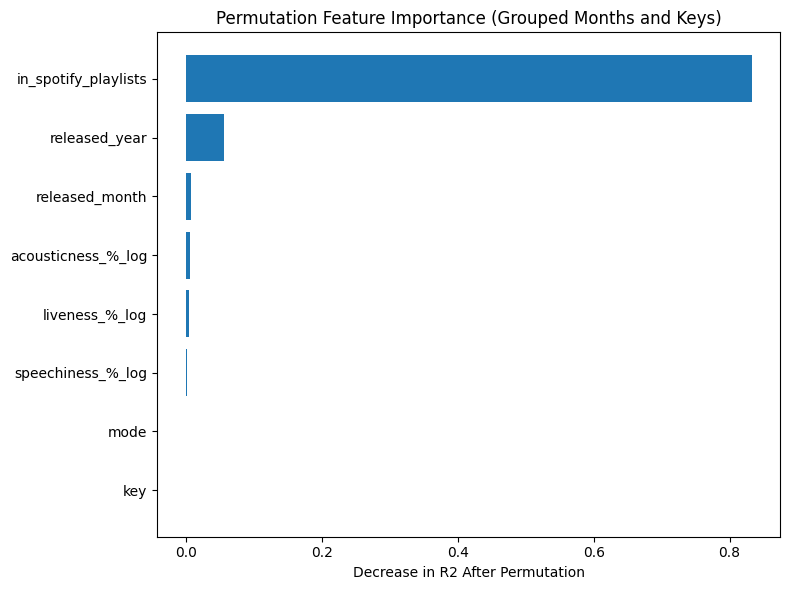

*Note: As permuting a highly informative feature can lead to negative R2 values (which indicate worse performance than predicting the mean), permutation importance can result in decreases in R2 that are larger than the model's original R2.*

**Permutation Feature Importance Analysis**

The permutation importance results show that `in_spotify_playlists` is the most influential feature. Permuting this variable leads to a substantial drop in R2, indicating that playlist exposure plays a dominant role in the model's predictive performance.

`released_year` demonstrates a smaller but still meaningful contribution to the model. This suggests that temporal factors, like the streaming platform's growth over time, do play a role in explaining predicted stream counts.

In contrast, grouped variables (released month and key of song), as well as audio characteristics, contribute minimally to the model's performance once playlist exposure is taken into account.

These findings closely align with the ablation study's results, which showed that removing data on playlist exposure caused a sharp decline in model performance. Together, these analyses confirm that the model primarily relies on playlist exposure data, rather than intrinsic audio characteristics of a song. This dependence suggests that the model is better interpreted as a predictor of a song's realised popularity after exposure, rather than as a tool for discovering high-potential songs before they are included in playlists.